# Fake News Detection in Crypto Domain
## EDA + Basic Preprocessing

**שם:** שיר אבוטבול
**ת.ז.:** 206639734

**שם:** בת-אל גדלוב
**ת.ז.:** 211307350

---

### מטרת הפרויקט
זיהוי פייק ניוז בתחום הקריפטו תוך שימוש בנתונים מ-Reddit וממאגרי מידע ציבוריים.  
הפרויקט משלב NLP קלאסי: ניקוי טקסט, חילוץ פיצ׳רים וויזואליזציה — כהכנה לבניית מודל סיווג.

---

### מקורות הדאטה

| מקור | כמות | תיאור |
|------|------|--------|
| LIAR Dataset (GitHub) | ~12,800 | הצהרות מתויגות ב-6 רמות אמינות, מומרות ל-FAKE/REAL |
| Fake/Real News (HuggingFace: GonzaloA/fake_news) | ~40,500 | כתבות חדשות מתויגות FAKE/REAL מדאטאסט Kaggle |
| Reddit Scraping | ~1,200 | פוסטים מ-r/CryptoCurrency, r/Bitcoin, r/Buttcoin, r/CryptoMoonShots |

**סה״כ:** ~54,500 רשומות לאחר איחוד

---

### מבנה ה-Notebook
1. התקנות וייבוא ספריות
2. איסוף נתונים (LIAR + Kaggle מ-HuggingFace + Reddit Scraping)
3. EDA — ניתוח סטטיסטי וויזואליזציות
4. עיבוד מקדים (ניקוי, הסרת stopwords, lemmatization, TF-IDF)
5. שמירת הנתונים המעובדים

### קישור לגיט
https://github.com/shirab13/fake-news-crypto

## 1. התקנות וייבוא ספריות

In [1]:
# התקנת ספריות נדרשות
!pip install datasets textblob wordcloud plotly python-dotenv tqdm -q


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import re
import time
import json
import random
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (12, 6)
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from collections import Counter
from wordcloud import WordCloud
from textblob import TextBlob
from tqdm import tqdm
from dotenv import load_dotenv

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)

load_dotenv('../.env')
os.makedirs('../data/raw', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

print('All imports successful!')


All imports successful!


## 2. איסוף נתונים

### 2.1 Dataset מוכן - LIAR Dataset

ה-LIAR dataset הוא אחד המאגרים המפורסמים לזיהוי פייק ניוז.
מכיל ~12,800 הצהרות מתויגות עם 6 רמות אמינות:
`pants-fire`, `false`, `barely-true`, `half-true`, `mostly-true`, `true`

In [3]:
print('Loading LIAR dataset from GitHub...')
import urllib.request, os

LIAR_COLS = ['id','label','statement','subject','speaker','job','state','party',
             'barely_true_c','false_c','half_true_c','mostly_true_c','pants_fire_c','venue']

for split, fname in [('train','train.tsv'),('val','valid.tsv'),('test','test.tsv')]:
    path = f'../data/raw/liar_{split}.tsv'
    if not os.path.exists(path):
        url = f'https://raw.githubusercontent.com/thiagorainmaker77/liar_dataset/master/{fname}'
        print(f'Downloading {fname}...')
        urllib.request.urlretrieve(url, path)

df_liar_train = pd.read_csv('../data/raw/liar_train.tsv', sep='	', header=None, names=LIAR_COLS)
df_liar_val   = pd.read_csv('../data/raw/liar_val.tsv',   sep='	', header=None, names=LIAR_COLS)
df_liar_test  = pd.read_csv('../data/raw/liar_test.tsv',  sep='	', header=None, names=LIAR_COLS)
df_liar = pd.concat([df_liar_train, df_liar_val, df_liar_test], ignore_index=True)

print(f'Total LIAR records: {len(df_liar):,}')
df_liar.head(3)


Loading LIAR dataset from GitHub...
Total LIAR records: 12,791


,id,label,statement,subject,speaker,job,state,party,barely_true_c,false_c,half_true_c,mostly_true_c,pants_fire_c,venue
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver


In [4]:
label_map = {
    'pants-fire': 0, 'false': 0, 'barely-true': 0,
    'half-true': 1, 'mostly-true': 1, 'true': 1
}
df_liar_clean = pd.DataFrame({
    'title'      : df_liar['statement'],
    'text'       : '',
    'label'      : df_liar['label'].map(label_map),
    'label_orig' : df_liar['label'].map(label_map).map({0: 'FAKE', 1: 'REAL'}),
    'subject'    : df_liar['subject'],
    'source'     : 'liar_dataset'
})
print(f'LIAR clean shape: {df_liar_clean.shape}')
print(df_liar_clean['label_orig'].value_counts())
df_liar_clean.head(3)


LIAR clean shape: (12791, 6)
label_orig
REAL    7134
FAKE    5657
Name: count, dtype: int64


,title,text,label,label_orig,subject,source
0,Says the Annies List political group supports ...,,0,FAKE,abortion,liar_dataset
1,When did the decline of coal start? It started...,,1,REAL,"energy,history,job-accomplishments",liar_dataset
2,"Hillary Clinton agrees with John McCain ""by vo...",,1,REAL,foreign-policy,liar_dataset


### 2.2 Dataset מוכן - Fake and Real News (Kaggle)
מאגר עם ~44,000 כתבות מתויגות FAKE/REAL

In [5]:
# Kaggle Fake/Real News Dataset - loaded from HuggingFace (GonzaloA/fake_news)
from datasets import load_dataset
import pandas as pd

print('Loading Kaggle fake/real news dataset from HuggingFace...')

ds = load_dataset('GonzaloA/fake_news')

# Combine all splits
df_parts = []
for split in ds.keys():
    df_parts.append(ds[split].to_pandas())
df_raw = pd.concat(df_parts, ignore_index=True)

# label: 0=FAKE, 1=REAL (already correct in this dataset)
df_kaggle = pd.DataFrame({
    'title':      df_raw['title'].fillna(''),
    'text':       df_raw['text'].fillna(''),
    'label':      df_raw['label'].astype(int),
    'source':     'kaggle_fake_news',
})

print(f'Loaded real dataset: {df_kaggle.shape}')
print(f'Label distribution:\n{df_kaggle["label"].value_counts().rename({0:"FAKE",1:"REAL"})}')
print(f'Columns: {list(df_kaggle.columns)}')
df_kaggle.head(3)


Loading Kaggle fake/real news dataset from HuggingFace...


Repo card metadata block was not found. Setting CardData to empty.


Loaded real dataset: (40587, 4)
Label distribution:
label
REAL    21924
FAKE    18663
Name: count, dtype: int64
Columns: ['title', 'text', 'label', 'source']


,title,text,label,source
0,‘Maury’ Show Official Facebook Posts F*CKED U...,Maury is perhaps one of the trashiest shows on...,0,kaggle_fake_news
1,Trump’s Favorite News Channel Tries To Soothe...,"Yesterday, after the father of one of the UCLA...",0,kaggle_fake_news
2,"Russia warns Iraq, Kurds not to destabilize Mi...",MOSCOW (Reuters) - Russia on Wednesday warned ...,1,kaggle_fake_news


In [6]:
df_kaggle_clean = pd.DataFrame({
    'title'      : df_kaggle['title'],
    'text'       : df_kaggle.get('text', pd.Series([''] * len(df_kaggle))),
    'label'      : df_kaggle['label'],
    'label_orig' : df_kaggle['label'].map({0: 'FAKE', 1: 'REAL'}),
    'subject'    : df_kaggle.get('subject', pd.Series(['news'] * len(df_kaggle))),
    'source'     : 'kaggle_fake_news'
})

print(f'Kaggle clean shape: {df_kaggle_clean.shape}')
print(df_kaggle_clean['label_orig'].value_counts())
df_kaggle_clean.head(3)


Kaggle clean shape: (40587, 6)
label_orig
REAL    21924
FAKE    18663
Name: count, dtype: int64


,title,text,label,label_orig,subject,source
0,‘Maury’ Show Official Facebook Posts F*CKED U...,Maury is perhaps one of the trashiest shows on...,0,FAKE,news,kaggle_fake_news
1,Trump’s Favorite News Channel Tries To Soothe...,"Yesterday, after the father of one of the UCLA...",0,FAKE,news,kaggle_fake_news
2,"Russia warns Iraq, Kurds not to destabilize Mi...",MOSCOW (Reuters) - Russia on Wednesday warned ...,1,REAL,news,kaggle_fake_news


### 2.3 Reddit Scraping - r/CryptoCurrency, r/Bitcoin, r/Buttcoin

שימוש ב-Reddit JSON API — **ללא צורך ב-API credentials**.
Reddit חושפת נתונים ציבוריים ישירות דרך URL פשוט.

In [7]:
def scrape_reddit(subreddits: list, posts_per_sub: int = 300) -> pd.DataFrame:
    """
    שולף פוסטים מ-subreddits נבחרים דרך Reddit JSON API (ללא credentials).
    לכל פוסט שולף: כותרת, טקסט, upvotes, תגובות, תאריך, URL
    """
    import requests

    headers = {'User-Agent': 'FakeNewsDetector/1.0 (educational project)'}

    # label לוגיקה:
    # r/Buttcoin = תוכן ביקורתי/סקפטי לגבי קריפטו -> נשתמש כסיגנל ל-FAKE/misleading
    # r/CryptoCurrency + r/Bitcoin = תוכן רגיל -> נשתמש upvote_ratio כ-proxy
    label_map_sub = {
        'CryptoCurrency' : None,   # label לפי upvote_ratio
        'Bitcoin'        : None,   # label לפי upvote_ratio
        'Buttcoin'       : 0,      # ביקורת/סקפטיות -> misleading
        'CryptoMoonShots': 0,      # pump-and-dump -> FAKE
    }

    all_posts = []

    for subreddit_name in subreddits:
        print(f'Scraping r/{subreddit_name}...')
        fetched = 0
        after = None

        while fetched < posts_per_sub:
            batch = min(100, posts_per_sub - fetched)
            url = f'https://www.reddit.com/r/{subreddit_name}/hot.json?limit={batch}'
            if after:
                url += f'&after={after}'

            try:
                resp = requests.get(url, headers=headers, timeout=10)
                if resp.status_code != 200:
                    print(f'  HTTP {resp.status_code} for r/{subreddit_name}')
                    break
                data = resp.json()
                children = data['data']['children']
                if not children:
                    break

                for child in children:
                    p = child['data']
                    upvote_ratio = p.get('upvote_ratio', 0.5)

                    if label_map_sub.get(subreddit_name) is not None:
                        auto_label = label_map_sub[subreddit_name]
                    else:
                        auto_label = 0 if upvote_ratio < 0.5 else 1

                    all_posts.append({
                        'title'        : p.get('title', ''),
                        'text'         : (p.get('selftext') or '')[:1000],
                        'score'        : p.get('score', 0),
                        'upvote_ratio' : upvote_ratio,
                        'num_comments' : p.get('num_comments', 0),
                        'url'          : p.get('url', ''),
                        'subreddit'    : subreddit_name,
                        'created_utc'  : pd.to_datetime(p.get('created_utc', 0), unit='s'),
                        'label'        : auto_label,
                        'label_orig'   : 'FAKE' if auto_label == 0 else 'REAL',
                        'source'       : f'reddit_{subreddit_name}'
                    })
                    fetched += 1

                after = data['data'].get('after')
                if not after:
                    break
                time.sleep(1)  # rate limiting - Reddit מגביל ל-1 req/sec

            except Exception as e:
                print(f'  Error scraping r/{subreddit_name}: {e}')
                break

        print(f'  -> Got {fetched} posts from r/{subreddit_name}')

    if not all_posts:
        print('WARNING: No posts fetched. Using mock data for demonstration.')
        return _generate_mock_reddit_data()

    df = pd.DataFrame(all_posts)
    os.makedirs('../data/raw', exist_ok=True)
    df.to_csv('../data/raw/reddit_raw.csv', index=False)
    print(f'\nTotal Reddit posts: {len(df):,}')
    return df


def _generate_mock_reddit_data(n=200):
    """נתוני Reddit מדומים להדגמה אם ה-API לא זמין"""
    import random
    fake_titles = [
        'Bitcoin to reach $1,000,000 by end of year - insider source',
        'BREAKING: Government to ban all crypto IMMEDIATELY',
        'This altcoin will 100x in 24 hours GUARANTEED',
        'Elon Musk secretly buying massive amounts of Dogecoin',
        'New crypto will replace Bitcoin completely by next month',
    ]
    real_titles = [
        'Bitcoin price analysis: current market trends and what analysts say',
        'Ethereum upgrade completed successfully, developers confirm',
        'SEC releases new guidelines for cryptocurrency exchanges',
        'Research shows blockchain adoption growing in enterprise sector',
        'Weekly discussion: thoughts on the current crypto market',
    ]
    rows = []
    for i in range(n):
        is_fake = random.random() < 0.4
        title = random.choice(fake_titles if is_fake else real_titles)
        rows.append({
            'title'       : title + f' #{i}',
            'text'        : '',
            'score'       : random.randint(1, 5000),
            'upvote_ratio': random.uniform(0.3, 0.6) if is_fake else random.uniform(0.7, 1.0),
            'num_comments': random.randint(0, 500),
            'subreddit'   : random.choice(['CryptoCurrency', 'Bitcoin', 'Buttcoin']),
            'created_utc' : pd.Timestamp.now() - pd.Timedelta(days=random.randint(0, 90)),
            'label'       : 0 if is_fake else 1,
            'label_orig'  : 'FAKE' if is_fake else 'REAL',
            'source'      : 'reddit_mock'
        })
    return pd.DataFrame(rows)

In [8]:
SUBREDDITS = ['CryptoCurrency', 'Bitcoin', 'Buttcoin', 'CryptoMoonShots']
df_reddit = scrape_reddit(SUBREDDITS, posts_per_sub=300)
print(df_reddit.shape)
df_reddit.head(3)

Scraping r/CryptoCurrency...
  -> Got 300 posts from r/CryptoCurrency
Scraping r/Bitcoin...
  -> Got 300 posts from r/Bitcoin
Scraping r/Buttcoin...
  -> Got 300 posts from r/Buttcoin
Scraping r/CryptoMoonShots...
  -> Got 300 posts from r/CryptoMoonShots

Total Reddit posts: 1,200
(1200, 11)


,title,text,score,upvote_ratio,num_comments,url,subreddit,created_utc,label,label_orig,source
0,"Daily Crypto Discussion - April 7, 2026 (GMT+0)",**Welcome to the Daily Crypto Discussion threa...,29,0.96,497,https://www.reddit.com/r/CryptoCurrency/commen...,CryptoCurrency,2026-04-07 23:00:30,1,REAL,reddit_CryptoCurrency
1,"No reels, just real gains",,1235,0.96,29,https://i.redd.it/zkl3jytiszug1.jpeg,CryptoCurrency,2026-04-13 17:25:27,1,REAL,reddit_CryptoCurrency
2,"Musician G. Love Loses $424,000 Bitcoin Retire...",,124,0.96,24,https://ourcryptotalk.com/news/g-love-loses-bi...,CryptoCurrency,2026-04-14 02:57:46,1,REAL,reddit_CryptoCurrency


### 2.4 איחוד כל הנתונים

In [9]:
# בניית DataFrame מאוחד עם עמודות אחידות
common_cols = ['title', 'text', 'label', 'label_orig', 'source']

# LIAR - אין עמודת text, נמלא בריק
df_liar_final = df_liar_clean.copy()
if 'text' not in df_liar_final.columns:
    df_liar_final['text'] = ''

# Reddit - יש כל העמודות
df_reddit_final = df_reddit[['title', 'text', 'label', 'label_orig', 'source',
                              'score', 'upvote_ratio', 'num_comments']].copy()

# Kaggle
df_kaggle_final = df_kaggle_clean.copy()
if 'text' not in df_kaggle_final.columns:
    df_kaggle_final['text'] = ''

# איחוד
df_all = pd.concat(
    [df_liar_final[common_cols],
     df_kaggle_final[common_cols],
     df_reddit_final[common_cols]],
    ignore_index=True
)

# הסרת כותרות ריקות
df_all = df_all[df_all['title'].notna() & (df_all['title'].str.strip() != '')]
df_all = df_all.drop_duplicates(subset='title')
df_all = df_all.reset_index(drop=True)

print(f'Total combined dataset: {len(df_all):,} records')
print(f"\nBy source:")
print(df_all['source'].value_counts())
print(f"\nLabel distribution:")
print(df_all['label'].value_counts())

Total combined dataset: 53,949 records

By source:
source
kaggle_fake_news          39997
liar_dataset              12765
reddit_Buttcoin             299
reddit_CryptoCurrency       298
reddit_Bitcoin              297
reddit_CryptoMoonShots      293
Name: count, dtype: int64

Label distribution:
label
1    29074
0    24875
Name: count, dtype: int64


In [10]:
# שמירת ה-raw combined dataset
df_all.to_csv('../data/raw/combined_raw.csv', index=False)
print('Saved to ../data/raw/combined_raw.csv')
df_all.info()

Saved to ../data/raw/combined_raw.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53949 entries, 0 to 53948
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   title       53949 non-null  object
 1   text        53949 non-null  object
 2   label       53949 non-null  int64 
 3   label_orig  53949 non-null  object
 4   source      53949 non-null  object
dtypes: int64(1), object(4)
memory usage: 2.1+ MB


---
## 3. EDA - Exploratory Data Analysis

### 3.1 סטטיסטיקות בסיסיות

In [11]:
# חישוב פיצ'רים סטטיסטיים על הכותרות
def compute_text_stats(df: pd.DataFrame, col: str = 'title') -> pd.DataFrame:
    df = df.copy()
    df['char_count']       = df[col].str.len()
    df['word_count']       = df[col].str.split().str.len()
    df['avg_word_len']     = df[col].apply(
        lambda x: np.mean([len(w) for w in str(x).split()]) if str(x).split() else 0
    )
    df['caps_word_count']  = df[col].apply(
        lambda x: sum(1 for w in str(x).split() if w.isupper() and len(w) > 1)
    )
    df['caps_ratio']       = df['caps_word_count'] / df['word_count'].replace(0, 1)
    df['exclamation_count']= df[col].str.count('!')
    df['question_count']   = df[col].str.count(r'\?')
    df['number_count']     = df[col].str.count(r'\d+')
    df['has_url']          = df[col].str.contains(r'http[s]?://', case=False).astype(int)
    df['special_char_count'] = df[col].apply(
        lambda x: sum(1 for c in str(x) if not c.isalnum() and c != ' ')
    )
    # TextBlob sentiment
    df['sentiment_polarity']    = df[col].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
    df['sentiment_subjectivity']= df[col].apply(lambda x: TextBlob(str(x)).sentiment.subjectivity)
    return df

print('Computing text statistics (this may take a minute)...')
df_stats = compute_text_stats(df_all, 'title')
print('Done!')
df_stats.describe().round(2)

Computing text statistics (this may take a minute)...
Done!


,label,char_count,word_count,avg_word_len,caps_word_count,caps_ratio,exclamation_count,question_count,number_count,has_url,special_char_count,sentiment_polarity,sentiment_subjectivity
count,53949.00,53949.00,53949.00,53949.00,53949.00,53949.00,53949.00,53949.00,53949.00,53949.00,53949.00,53949.00,53949.00
mean,0.54,83.47,13.34,5.45,1.06,0.08,0.04,0.03,0.27,0.00,2.35,0.03,0.27
std,0.50,39.32,6.52,1.31,2.02,0.14,0.23,0.20,0.92,0.01,2.92,0.25,0.31
min,0.00,2.00,1.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-1.00,0.00
25%,0.00,63.00,10.00,4.88,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
50%,1.00,74.00,12.00,5.36,0.00,0.00,0.00,0.00,0.00,0.00,2.00,0.00,0.10
75%,1.00,94.00,15.00,5.91,1.00,0.10,0.00,0.00,0.00,0.00,3.00,0.07,0.50
max,1.00,3192.00,467.00,149.00,24.00,1.00,5.00,23.00,83.00,1.00,287.00,1.00,1.00


In [12]:
# השוואה סטטיסטית: FAKE vs REAL
numeric_cols = ['char_count', 'word_count', 'avg_word_len', 'caps_ratio',
                'exclamation_count', 'number_count', 'sentiment_polarity', 'sentiment_subjectivity']

comparison = df_stats.groupby('label')[numeric_cols].mean().round(3)
comparison.index = ['FAKE (0)', 'REAL (1)']
print('=== ממוצעים: FAKE vs REAL ===' )
comparison

=== ממוצעים: FAKE vs REAL ===


,char_count,word_count,avg_word_len,caps_ratio,exclamation_count,number_count,sentiment_polarity,sentiment_subjectivity
FAKE (0),92.587,14.820,5.385,0.135,0.090,0.242,0.015,0.340
REAL (1),75.661,12.075,5.506,0.030,0.002,0.292,0.033,0.202


### 3.2 ויזואליזציות - התפלגות Labels

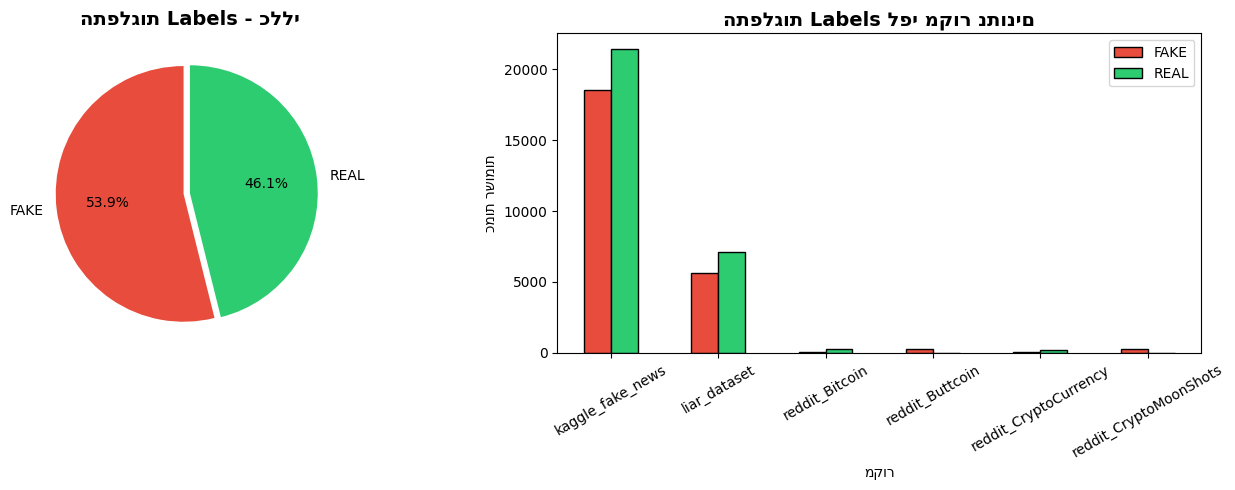

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# פאי - התפלגות כללית
label_counts = df_stats['label'].value_counts()
axes[0].pie(
    label_counts.values,
    labels=['FAKE', 'REAL'],
    autopct='%1.1f%%',
    colors=['#e74c3c', '#2ecc71'],
    startangle=90,
    explode=[0.05, 0]
)
axes[0].set_title('התפלגות Labels - כללי', fontsize=14, fontweight='bold')

# בר - לפי מקור
source_label = df_stats.groupby(['source', 'label']).size().unstack(fill_value=0)
source_label.columns = ['FAKE', 'REAL']
source_label.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[1].set_title('התפלגות Labels לפי מקור נתונים', fontsize=14, fontweight='bold')
axes[1].set_xlabel('מקור')
axes[1].set_ylabel('כמות רשומות')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../data/processed/plot_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 ניתוח אורך כותרות

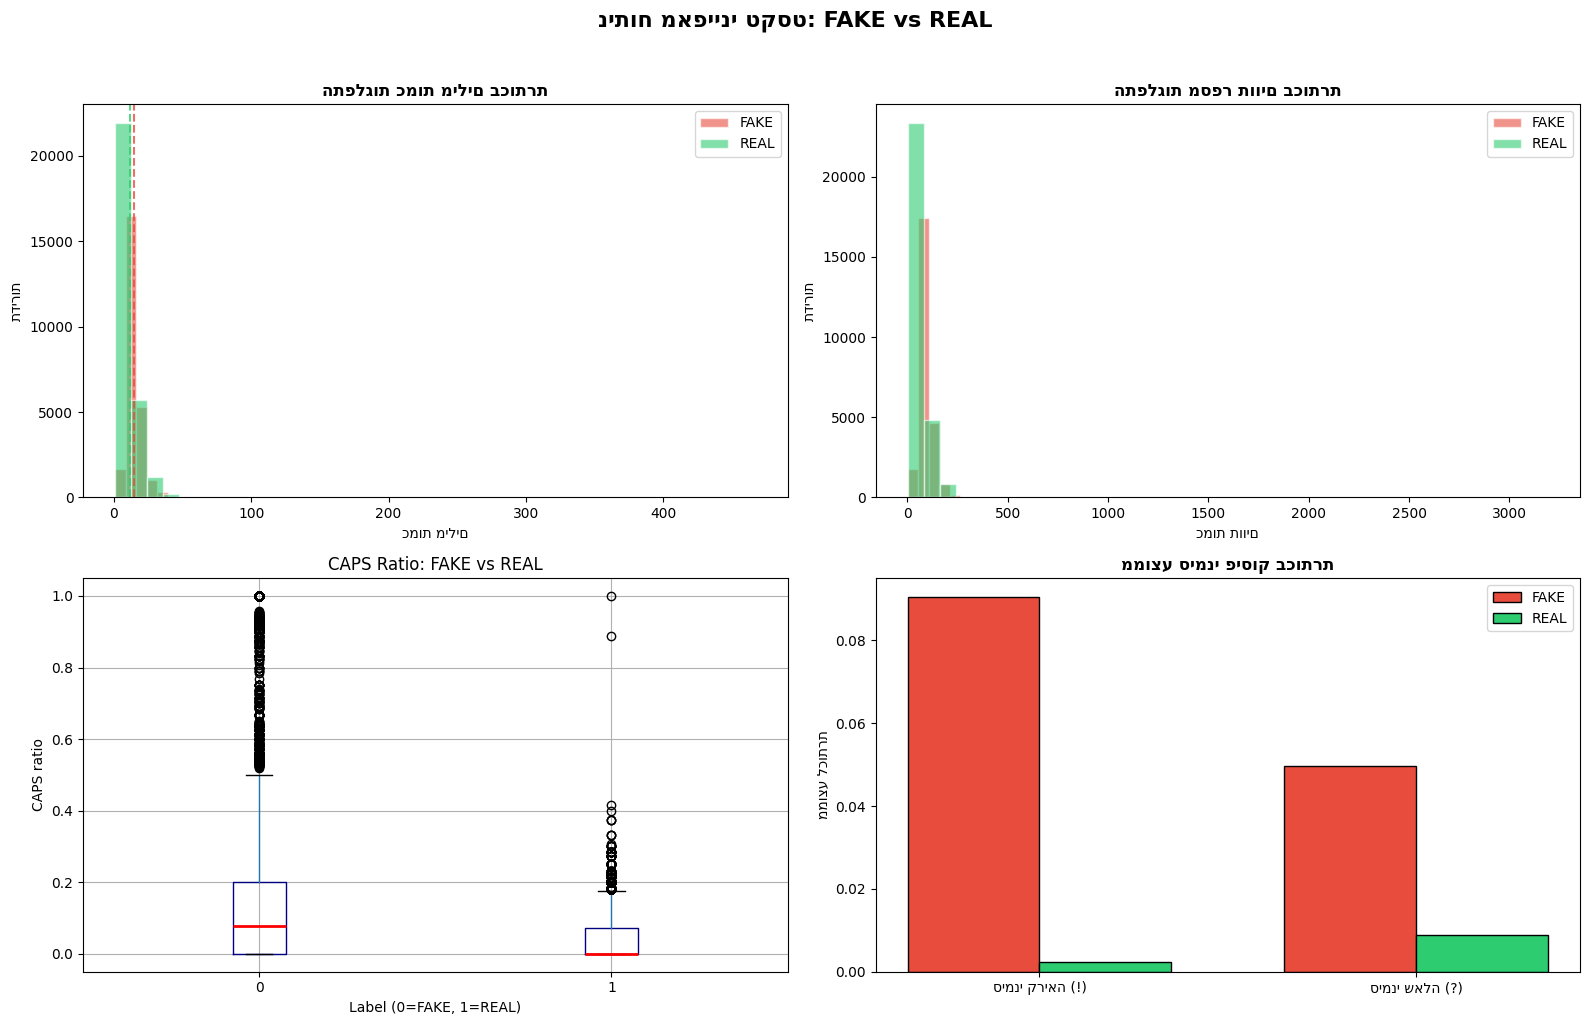

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. אורך כותרת (מילים) - FAKE vs REAL
for label, color, name in [(0, '#e74c3c', 'FAKE'), (1, '#2ecc71', 'REAL')]:
    subset = df_stats[df_stats['label'] == label]['word_count']
    axes[0, 0].hist(subset, bins=40, alpha=0.6, color=color, label=name, edgecolor='white')
axes[0, 0].set_title('התפלגות כמות מילים בכותרת', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('כמות מילים')
axes[0, 0].set_ylabel('תדירות')
axes[0, 0].legend()
axes[0, 0].axvline(df_stats[df_stats['label']==0]['word_count'].mean(), color='#e74c3c', linestyle='--', alpha=0.8)
axes[0, 0].axvline(df_stats[df_stats['label']==1]['word_count'].mean(), color='#2ecc71', linestyle='--', alpha=0.8)

# 2. אורך כותרת (תווים)
for label, color, name in [(0, '#e74c3c', 'FAKE'), (1, '#2ecc71', 'REAL')]:
    subset = df_stats[df_stats['label'] == label]['char_count']
    axes[0, 1].hist(subset, bins=40, alpha=0.6, color=color, label=name, edgecolor='white')
axes[0, 1].set_title('התפלגות מספר תווים בכותרת', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('כמות תווים')
axes[0, 1].set_ylabel('תדירות')
axes[0, 1].legend()

# 3. CAPS ratio - האם פייק ניוז "צועק" יותר?
df_stats.boxplot(column='caps_ratio', by='label', ax=axes[1, 0],
                 boxprops=dict(color='navy'),
                 medianprops=dict(color='red', linewidth=2))
axes[1, 0].set_title('יחס מילים באותיות גדולות (CAPS) - FAKE vs REAL', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Label (0=FAKE, 1=REAL)')
axes[1, 0].set_ylabel('CAPS ratio')
plt.sca(axes[1, 0])
plt.title('CAPS Ratio: FAKE vs REAL')

# 4. סימני קריאה + שאלה
punc_fake = df_stats[df_stats['label']==0][['exclamation_count', 'question_count']].mean()
punc_real = df_stats[df_stats['label']==1][['exclamation_count', 'question_count']].mean()
x = np.arange(2)
width = 0.35
axes[1, 1].bar(x - width/2, punc_fake.values, width, label='FAKE', color='#e74c3c', edgecolor='black')
axes[1, 1].bar(x + width/2, punc_real.values, width, label='REAL', color='#2ecc71', edgecolor='black')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(['סימני קריאה (!)', 'סימני שאלה (?)'])
axes[1, 1].set_title('ממוצע סימני פיסוק בכותרת', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('ממוצע לכותרת')
axes[1, 1].legend()

plt.suptitle('ניתוח מאפייני טקסט: FAKE vs REAL', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/plot_text_features.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 ניתוח Sentiment

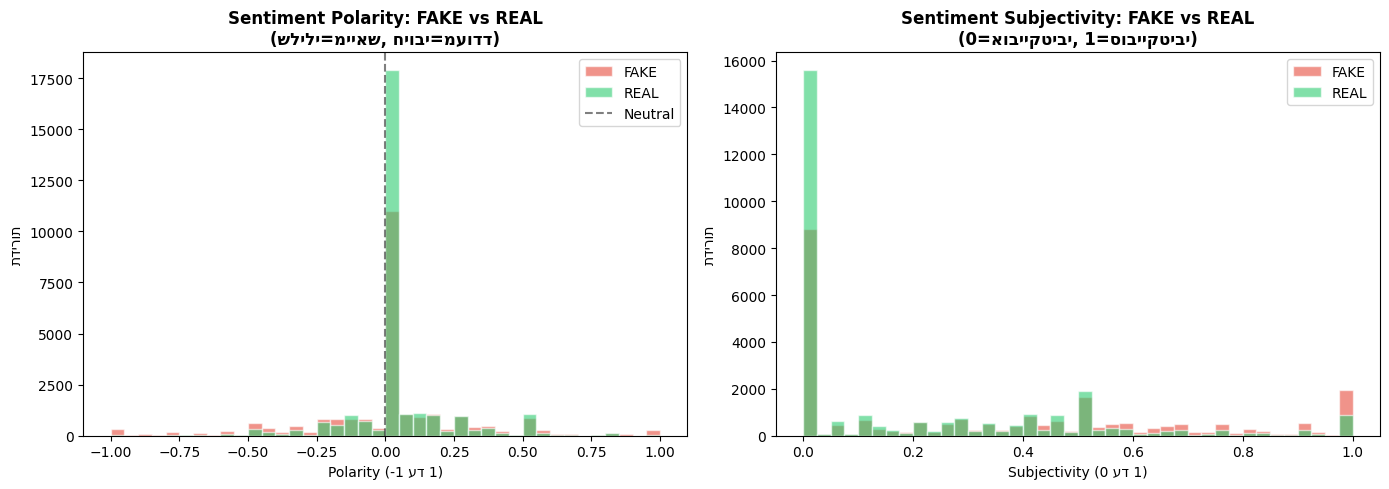


=== Sentiment Summary ===
      sentiment_polarity                                             \
                   count   mean    std  min    25%  50%    75%  max   
label                                                                 
0                24875.0  0.015  0.300 -1.0 -0.037  0.0  0.115  1.0   
1                29074.0  0.033  0.195 -1.0  0.000  0.0  0.031  1.0   

      sentiment_subjectivity                                           
                       count   mean    std  min  25%  50%    75%  max  
label                                                                  
0                    24875.0  0.340  0.336  0.0  0.0  0.3  0.567  1.0  
1                    29074.0  0.202  0.277  0.0  0.0  0.0  0.400  1.0  


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Polarity
for label, color, name in [(0, '#e74c3c', 'FAKE'), (1, '#2ecc71', 'REAL')]:
    subset = df_stats[df_stats['label'] == label]['sentiment_polarity']
    axes[0].hist(subset, bins=40, alpha=0.6, color=color, label=name, edgecolor='white')
axes[0].axvline(0, color='black', linestyle='--', alpha=0.5, label='Neutral')
axes[0].set_title('Sentiment Polarity: FAKE vs REAL\n(שלילי=מייאש, חיובי=מעודד)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Polarity (-1 עד 1)')
axes[0].set_ylabel('תדירות')
axes[0].legend()

# Subjectivity
for label, color, name in [(0, '#e74c3c', 'FAKE'), (1, '#2ecc71', 'REAL')]:
    subset = df_stats[df_stats['label'] == label]['sentiment_subjectivity']
    axes[1].hist(subset, bins=40, alpha=0.6, color=color, label=name, edgecolor='white')
axes[1].set_title('Sentiment Subjectivity: FAKE vs REAL\n(0=אובייקטיבי, 1=סובייקטיבי)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Subjectivity (0 עד 1)')
axes[1].set_ylabel('תדירות')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/plot_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== Sentiment Summary ===')
print(df_stats.groupby('label')[['sentiment_polarity', 'sentiment_subjectivity']].describe().round(3))

### 3.5 Word Cloud - מילים נפוצות

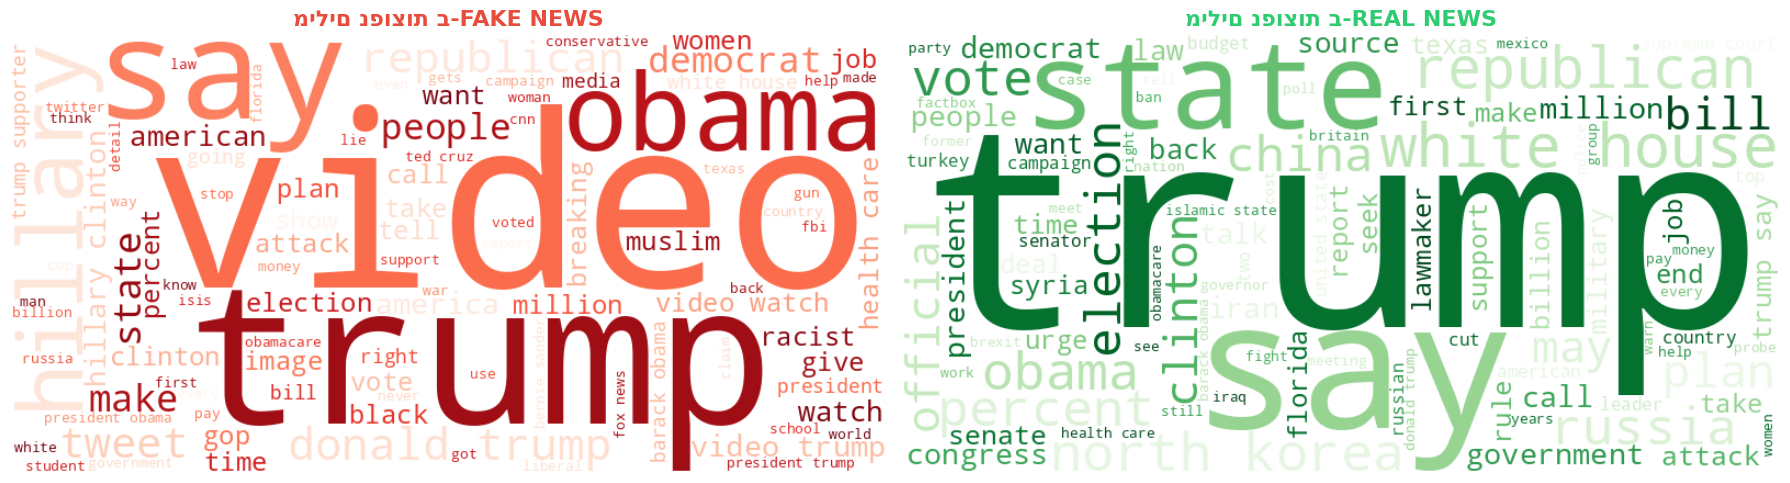

In [16]:
stop_words = set(stopwords.words('english'))
# מילים ספציפיות שרוצים להוסיף ל-stopwords
extra_stops = {'new', 'one', 'will', 'said', 'also', 'like', 'could', 'would', 'year', 'day'}
stop_words.update(extra_stops)

def get_words(df_subset, col='title'):
    text = ' '.join(df_subset[col].fillna('').str.lower())
    words = re.findall(r'\b[a-z]{3,}\b', text)
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

fake_text = get_words(df_stats[df_stats['label'] == 0])
real_text = get_words(df_stats[df_stats['label'] == 1])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

wc_fake = WordCloud(width=800, height=400, background_color='white',
                    colormap='Reds', max_words=100).generate(fake_text)
axes[0].imshow(wc_fake, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('מילים נפוצות ב-FAKE NEWS', fontsize=16, fontweight='bold', color='#e74c3c')

wc_real = WordCloud(width=800, height=400, background_color='white',
                    colormap='Greens', max_words=100).generate(real_text)
axes[1].imshow(wc_real, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('מילים נפוצות ב-REAL NEWS', fontsize=16, fontweight='bold', color='#2ecc71')

plt.tight_layout()
plt.savefig('../data/processed/plot_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

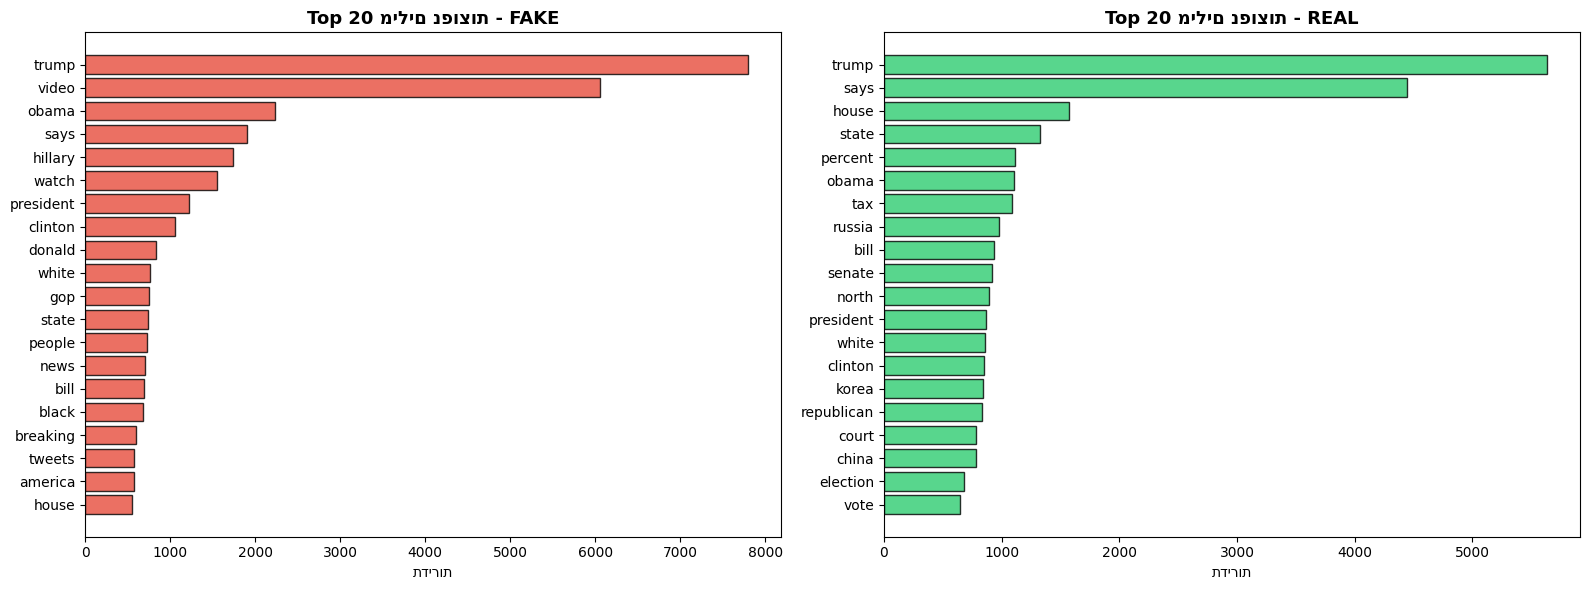

In [17]:
# Top 20 מילים נפוצות - FAKE vs REAL
def top_words(text, n=20):
    words = text.split()
    return Counter(words).most_common(n)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, text, label, color in [
    (axes[0], fake_text, 'FAKE', '#e74c3c'),
    (axes[1], real_text, 'REAL', '#2ecc71')
]:
    words, counts = zip(*top_words(text, 20))
    ax.barh(words[::-1], counts[::-1], color=color, edgecolor='black', alpha=0.8)
    ax.set_title(f'Top 20 מילים נפוצות - {label}', fontsize=13, fontweight='bold')
    ax.set_xlabel('תדירות')

plt.tight_layout()
plt.savefig('../data/processed/plot_top_words.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.6 Correlation Heatmap - קורלציה בין פיצ'רים

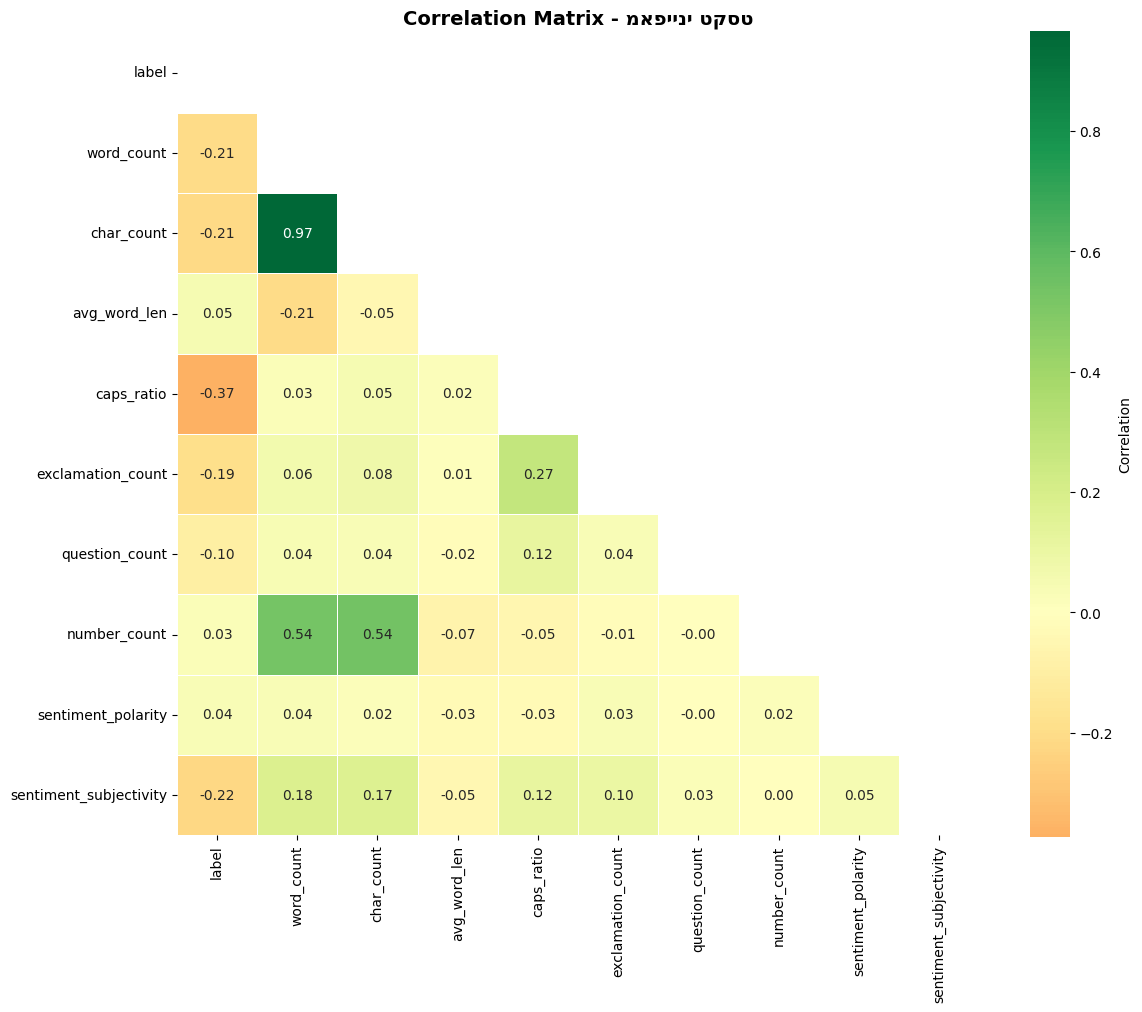

In [18]:
corr_cols = ['label', 'word_count', 'char_count', 'avg_word_len', 'caps_ratio',
             'exclamation_count', 'question_count', 'number_count',
             'sentiment_polarity', 'sentiment_subjectivity']

corr_matrix = df_stats[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, square=True, linewidths=0.5,
    cbar_kws={'label': 'Correlation'},
    ax=ax
)
ax.set_title('Correlation Matrix - מאפייני טקסט', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/plot_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. עיבוד מקדים (Preprocessing)

### 4.1 ניקוי טקסט

In [19]:
lemmatizer = WordNetLemmatizer()
stemmer    = PorterStemmer()


def clean_text(text: str) -> str:
    """שלב 1: ניקוי בסיסי"""
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)        # הסרת URLs
    text = re.sub(r'@\w+|#\w+', '', text)               # הסרת @mentions ו-#hashtags
    text = re.sub(r'[^a-z0-9\s]', ' ', text)            # הסרת תווים מיוחדים
    text = re.sub(r'\d+', 'NUM', text)                   # החלפת מספרים ב-NUM
    text = re.sub(r'\s+', ' ', text).strip()             # הסרת רווחים כפולים
    return text


def remove_stopwords(text: str) -> str:
    """שלב 2: הסרת stopwords"""
    tokens = text.split()
    return ' '.join([w for w in tokens if w not in stop_words and len(w) > 2])


def lemmatize_text(text: str) -> str:
    """שלב 3: Lemmatization - החזרת מילים לשורש"""
    tokens = word_tokenize(text)
    return ' '.join([lemmatizer.lemmatize(w) for w in tokens])


def full_preprocess(text: str) -> str:
    """Pipeline מלא של עיבוד מקדים"""
    text = clean_text(text)
    text = remove_stopwords(text)
    text = lemmatize_text(text)
    return text


# דוגמה
sample = 'BREAKING!!! Bitcoin will CRASH 90% next week! Elon Musk says so https://scam.com'
print(f'Original:    {sample}')
print(f'Clean:       {clean_text(sample)}')
print(f'No stops:    {remove_stopwords(clean_text(sample))}')
print(f'Lemmatized:  {full_preprocess(sample)}')

Original:    BREAKING!!! Bitcoin will CRASH 90% next week! Elon Musk says so https://scam.com
Clean:       breaking bitcoin will crash NUM next week elon musk says so
No stops:    breaking bitcoin crash NUM next week elon musk says
Lemmatized:  breaking bitcoin crash NUM next week elon musk say


In [20]:
print('Running preprocessing pipeline...')
df_processed = df_stats.copy()
df_processed['title_clean']   = df_processed['title'].apply(clean_text)
df_processed['title_no_stop'] = df_processed['title_clean'].apply(remove_stopwords)
df_processed['title_lemma']   = df_processed['title_no_stop'].apply(lemmatize_text)

# token count לאחר עיבוד
df_processed['tokens_after'] = df_processed['title_lemma'].str.split().str.len()

print('Done!')
print(f'\nממוצע מילים לפני עיבוד: {df_processed["word_count"].mean():.1f}')
print(f'ממוצע מילים אחרי עיבוד: {df_processed["tokens_after"].mean():.1f}')
print(f'צמצום: {(1 - df_processed["tokens_after"].mean()/df_processed["word_count"].mean())*100:.1f}%')

# הצגת לפני/אחרי
df_processed[['title', 'title_lemma', 'label']].head(5)

Running preprocessing pipeline...
Done!

ממוצע מילים לפני עיבוד: 13.3
ממוצע מילים אחרי עיבוד: 9.3
צמצום: 30.6%


,title,title_lemma,label
0,Says the Annies List political group supports ...,say annies list political group support third ...,0
1,When did the decline of coal start? It started...,decline coal start started natural gas took st...,1
2,"Hillary Clinton agrees with John McCain ""by vo...",hillary clinton agrees john mccain voting give...,1
3,Health care reform legislation is likely to ma...,health care reform legislation likely mandate ...,0
4,The economic turnaround started at the end of ...,economic turnaround started end term,1


### 4.2 ייצוג וקטורי - TF-IDF (הדגמה ראשונית)

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
X_tfidf = tfidf.fit_transform(df_processed['title_lemma'])

print(f'TF-IDF Matrix shape: {X_tfidf.shape}')
print(f'Vocabulary size: {len(tfidf.vocabulary_):,}')

# Top TF-IDF terms per label
from sklearn.feature_selection import chi2

y = df_processed['label']
chi2_scores, _ = chi2(X_tfidf, y)
feature_names  = np.array(tfidf.get_feature_names_out())
top_features   = feature_names[np.argsort(chi2_scores)[-20:][::-1]]

print(f'\nTop 20 most discriminative features (Chi2):')
print(top_features)

TF-IDF Matrix shape: (53949, 5000)
Vocabulary size: 5,000

Top 20 most discriminative features (Chi2):
['video' 'watch' 'hillary' 'tweet' 'gop' 'breaking' 'korea' 'racist'
 'black' 'donald' 'donald trump' 'north' 'north korea' 'china' 'say'
 'image' 'brexit' 'news' 'cop' 'talk']


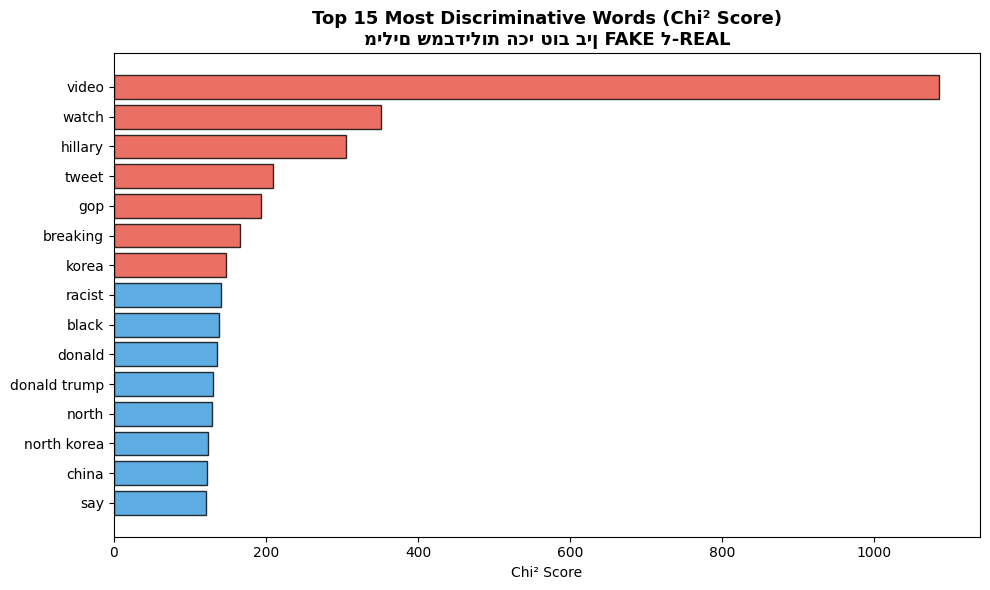

In [22]:
# ויזואליזציה: Top discriminative words
top_n = 15
top_idx = np.argsort(chi2_scores)[-top_n:][::-1]
top_words_chi2  = feature_names[top_idx]
top_scores_chi2 = chi2_scores[top_idx]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if s > np.median(top_scores_chi2) else '#3498db' for s in top_scores_chi2]
ax.barh(top_words_chi2[::-1], top_scores_chi2[::-1], color=colors[::-1], edgecolor='black', alpha=0.8)
ax.set_title(f'Top {top_n} Most Discriminative Words (Chi² Score)\nמילים שמבדילות הכי טוב בין FAKE ל-REAL',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Chi² Score')
plt.tight_layout()
plt.savefig('../data/processed/plot_tfidf_features.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. סיכום ה-EDA

In [23]:
print('=' * 60)
print('           EDA SUMMARY REPORT')
print('=' * 60)

print(f'\n📊 גודל Dataset:')
print(f'   Total records:     {len(df_all):,}')
print(f'   FAKE records:      {(df_all["label"]==0).sum():,} ({(df_all["label"]==0).mean()*100:.1f}%)')
print(f'   REAL records:      {(df_all["label"]==1).sum():,} ({(df_all["label"]==1).mean()*100:.1f}%)')
print(f'   Unique titles:     {df_all["title"].nunique():,}')

print(f'\n📝 מאפייני טקסט (ממוצע):')
for col, label in [('word_count', 'כמות מילים'), ('char_count', 'כמות תווים'),
                    ('caps_ratio', 'יחס CAPS'), ('exclamation_count', 'סימני קריאה')]:
    fake_mean = df_stats[df_stats['label']==0][col].mean()
    real_mean = df_stats[df_stats['label']==1][col].mean()
    print(f'   {label}: FAKE={fake_mean:.2f} | REAL={real_mean:.2f}')

print(f'\n🎭 Sentiment (ממוצע):')
fake_pol = df_stats[df_stats['label']==0]['sentiment_polarity'].mean()
real_pol = df_stats[df_stats['label']==1]['sentiment_polarity'].mean()
fake_sub = df_stats[df_stats['label']==0]['sentiment_subjectivity'].mean()
real_sub = df_stats[df_stats['label']==1]['sentiment_subjectivity'].mean()
print(f'   Polarity:     FAKE={fake_pol:.3f} | REAL={real_pol:.3f}')
print(f'   Subjectivity: FAKE={fake_sub:.3f} | REAL={real_sub:.3f}')

print(f'\n🔧 לאחר עיבוד מקדים:')
print(f'   ממוצע tokens לפני: {df_processed["word_count"].mean():.1f}')
print(f'   ממוצע tokens אחרי: {df_processed["tokens_after"].mean():.1f}')
print(f'   TF-IDF matrix: {X_tfidf.shape}')
print('\n' + '=' * 60)

           EDA SUMMARY REPORT

📊 גודל Dataset:
   Total records:     53,949
   FAKE records:      24,875 (46.1%)
   REAL records:      29,074 (53.9%)
   Unique titles:     53,949

📝 מאפייני טקסט (ממוצע):
   כמות מילים: FAKE=14.82 | REAL=12.07
   כמות תווים: FAKE=92.59 | REAL=75.66
   יחס CAPS: FAKE=0.13 | REAL=0.03
   סימני קריאה: FAKE=0.09 | REAL=0.00

🎭 Sentiment (ממוצע):
   Polarity:     FAKE=0.015 | REAL=0.033
   Subjectivity: FAKE=0.340 | REAL=0.202

🔧 לאחר עיבוד מקדים:
   ממוצע tokens לפני: 13.3
   ממוצע tokens אחרי: 9.3
   TF-IDF matrix: (53949, 5000)



## 6. שמירת הנתונים המעובדים

In [24]:
# שמירת processed dataset
save_cols = ['title', 'title_clean', 'title_lemma', 'label', 'label_orig', 'source',
             'word_count', 'char_count', 'caps_ratio', 'exclamation_count',
             'sentiment_polarity', 'sentiment_subjectivity', 'tokens_after']

df_save = df_processed[save_cols].copy()
df_save.to_csv('../data/processed/dataset_processed.csv', index=False)

print(f'Saved processed dataset: {df_save.shape}')
print('Files saved:')
print('  ../data/raw/combined_raw.csv')
print('  ../data/processed/dataset_processed.csv')
print('  ../data/processed/plot_*.png')

Saved processed dataset: (53949, 13)
Files saved:
  ../data/raw/combined_raw.csv
  ../data/processed/dataset_processed.csv
  ../data/processed/plot_*.png
